# Synthetic Control

## Goal

I want to estimate what Baltimore's port activity would have looked like if the bridge collapse had not happened.

Synthetic Control creates this counterfactual using a weighted combination of untreated ports.

April 2024 is the first full treatment month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/all_ports_imports.csv")

df["time"] = pd.to_datetime(df["time"])
df["VES_VAL_MO"] = pd.to_numeric(df["VES_VAL_MO"])
df["VES_WGT_MO"] = pd.to_numeric(df["VES_WGT_MO"])

df.head()

,VES_VAL_MO,VES_WGT_MO,PORT_NAME,time,PORT,port
0,3439162614,1213524503,"BALTIMORE, MD",2019-01-01,1303,Baltimore
1,3503063676,1120493870,"BALTIMORE, MD",2019-02-01,1303,Baltimore
2,3719890098,1063839057,"BALTIMORE, MD",2019-03-01,1303,Baltimore
3,4139140781,1075456430,"BALTIMORE, MD",2019-04-01,1303,Baltimore
4,3991269456,1197129890,"BALTIMORE, MD",2019-05-01,1303,Baltimore


In [2]:
df.groupby("port").size()

port
Baltimore          91
Boston             91
Brunswick          91
Charleston         91
Corpus Christi     91
Houston            91
Jacksonville       91
New Orleans        91
Norfolk            91
Oakland            91
Port Canaveral     91
Port Everglades    91
Portland OR        91
Savannah           91
Seattle            91
Tacoma             91
Tampa              91
dtype: int64

## Pre-Treatment Comparison

A good synthetic control should reproduce Baltimore's pattern before the bridge collapse.

I first compare Baltimore with the donor ports before April 2024.

In [3]:
pre = df[df["time"] < "2024-04-01"]

pivot = pre.pivot(
    index="time",
    columns="port",
    values="VES_VAL_MO"
)

pivot.corr()["Baltimore"].sort_values(ascending=False)

port
Baltimore          1.000000
Norfolk            0.821669
Houston            0.817546
Brunswick          0.805993
Tampa              0.768369
Boston             0.751439
Charleston         0.750339
Port Everglades    0.740936
Savannah           0.676328
Portland OR        0.641030
New Orleans        0.640974
Port Canaveral     0.614606
Jacksonville       0.604025
Corpus Christi     0.386765
Oakland            0.255666
Tacoma             0.224840
Seattle            0.094767
Name: Baltimore, dtype: float64

## Donor Pool Check

Norfolk and Houston have the strongest pre-treatment correlation with Baltimore.

However, correlation alone does not determine the synthetic control. The method will choose weights that best reproduce Baltimore's full pre-treatment path.

I exclude Norfolk because the Port of Virginia received cargo diverted from Baltimore after the bridge collapse. Using it as a control could contaminate the counterfactual.

In [4]:
import numpy as np
from scipy.optimize import minimize

wide = df.pivot(
    index="time",
    columns="port",
    values="VES_VAL_MO"
) / 1e9

donors = [
    port for port in wide.columns
    if port not in ["Baltimore", "Norfolk"]
]

pre = wide[wide.index < "2024-04-01"]

X1 = pre["Baltimore"].values
X0 = pre[donors].values

In [5]:
import numpy as np
from scipy.optimize import minimize

def loss(weights):
    return np.mean((X1 - X0 @ weights) ** 2)

start = np.repeat(1 / len(donors), len(donors))

result = minimize(
    loss,
    start,
    bounds=[(0, 1)] * len(donors),
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
)

weights = pd.Series(result.x, index=donors)

weights.sort_values(ascending=False)

Brunswick          3.762643e-01
Tacoma             2.370154e-01
Houston            2.263098e-01
Savannah           1.604105e-01
Corpus Christi     7.606180e-17
Seattle            4.757794e-17
Port Canaveral     3.798042e-17
Charleston         3.679121e-17
Boston             2.740656e-17
New Orleans        0.000000e+00
Jacksonville       0.000000e+00
Portland OR        0.000000e+00
Port Everglades    0.000000e+00
Oakland            0.000000e+00
Tampa              0.000000e+00
dtype: float64

## Updated Synthetic Control Weights

With a larger donor pool, the synthetic control uses four main ports:

- Brunswick: 37.6%
- Tacoma: 23.7%
- Houston: 22.6%
- Savannah: 16.0%

The remaining ports receive almost zero weight.

These weights are chosen to reproduce Baltimore's pre-treatment trend as closely as possible.

In [6]:
synthetic = wide[donors] @ weights

result_df = pd.DataFrame({
    "Baltimore": wide["Baltimore"],
    "Synthetic": synthetic
})

pre_result = result_df[result_df.index < "2024-04-01"]

rmse = (
    (pre_result["Baltimore"] - pre_result["Synthetic"]) ** 2
).mean() ** 0.5

rmse

np.float64(0.38716997326500613)

In [7]:
result_df["gap"] = (
    result_df["Baltimore"] - result_df["Synthetic"]
)

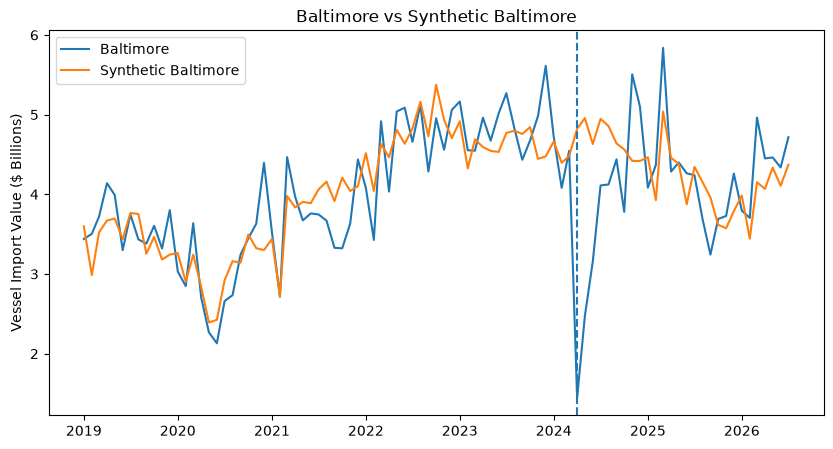

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(result_df.index, result_df["Baltimore"], label="Baltimore")
plt.plot(result_df.index, result_df["Synthetic"], label="Synthetic Baltimore")

plt.axvline(pd.Timestamp("2024-04-01"), linestyle="--")

plt.title("Baltimore vs Synthetic Baltimore")
plt.ylabel("Vessel Import Value ($ Billions)")
plt.legend()

plt.show()

In [9]:
result_df.loc[
    "2024-04-01":"2024-07-01",
    ["Baltimore", "Synthetic", "gap"]
]

,Baltimore,Synthetic,gap
time,,,
2024-04-01,1.444670,4.823043,-3.378374
2024-05-01,2.469054,4.956051,-2.486997
2024-06-01,3.161019,4.630346,-1.469327
2024-07-01,4.110759,4.947725,-0.836966


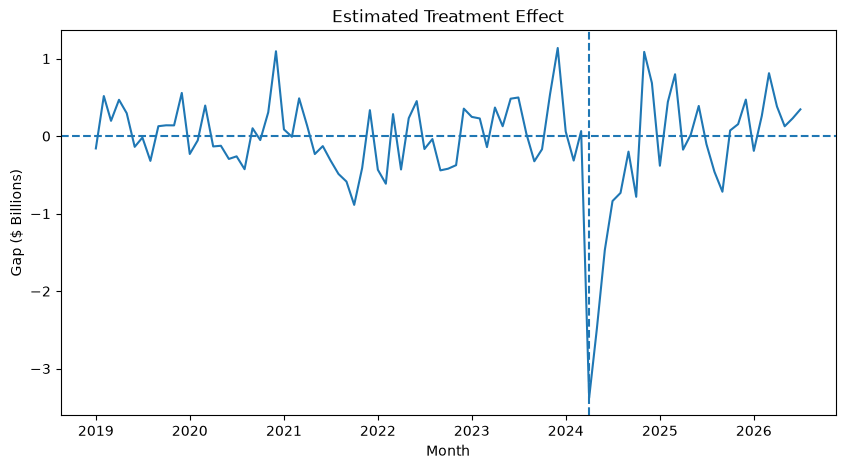

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(result_df.index, result_df["gap"])
plt.axhline(0, linestyle="--")
plt.axvline(pd.Timestamp("2024-04-01"), linestyle="--")

plt.title("Estimated Treatment Effect")
plt.ylabel("Gap ($ Billions)")
plt.xlabel("Month")

plt.show()

## Treatment Effect

Compared with Synthetic Baltimore:

- April: $3.38B below expected
- May: $2.49B below expected
- June: $1.47B below expected
- July: $0.84B below expected

The cumulative April-July gap is about $8.17B.

The effect is largest immediately after the collapse and shrinks over time, which is consistent with gradual port recovery.

## Placebo Test

I repeat the Synthetic Control procedure for untreated ports.

If Baltimore shows a much larger post-treatment gap than the placebo ports, the bridge-collapse effect becomes more credible.

In [11]:
def get_gap(treated, donors):

    pre = wide[wide.index < "2024-04-01"]

    X1 = pre[treated].values
    X0 = pre[donors].values

    def loss(w):
        return np.mean((X1 - X0 @ w) ** 2)

    start = np.repeat(1 / len(donors), len(donors))

    result = minimize(
        loss,
        start,
        bounds=[(0, 1)] * len(donors),
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
    )

    synthetic = wide[donors] @ result.x

    return wide[treated] - synthetic

In [12]:
placebo_gaps = {}

for port in donors:
    other_donors = [p for p in donors if p != port]
    placebo_gaps[port] = get_gap(port, other_donors)

placebo_gaps["Baltimore"] = result_df["gap"]

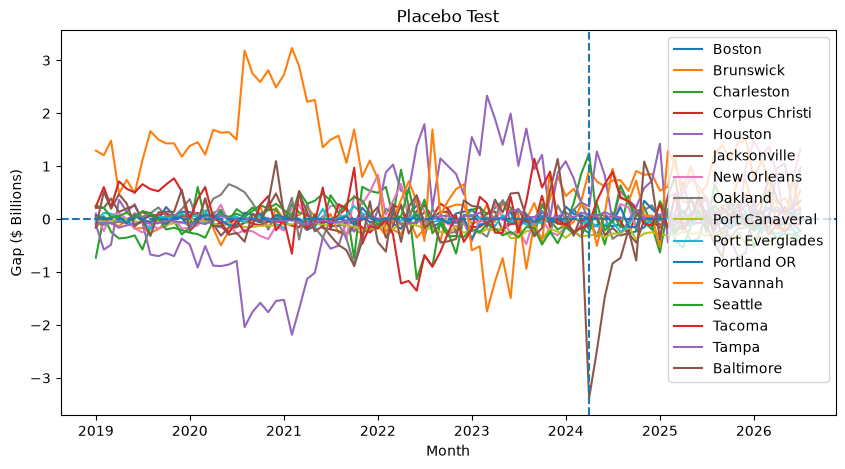

In [13]:
plt.figure(figsize=(10, 5))

for port, gap in placebo_gaps.items():
    plt.plot(gap.index, gap, label=port)

plt.axhline(0, linestyle="--")
plt.axvline(pd.Timestamp("2024-04-01"), linestyle="--")

plt.title("Placebo Test")
plt.ylabel("Gap ($ Billions)")
plt.xlabel("Month")
plt.legend()

plt.show()

## Placebo Test Interpretation

Baltimore shows the largest immediate negative gap after April 2024.

However, some placebo ports also have large pre-treatment errors. A placebo with poor pre-treatment fit is not a strong comparison.

I therefore compare each port's post-treatment error with its own pre-treatment error.

In [14]:
ratios = {}

for port, gap in placebo_gaps.items():

    pre_gap = gap[gap.index < "2024-04-01"]
    post_gap = gap[gap.index >= "2024-04-01"]

    pre_rmse = np.sqrt(np.mean(pre_gap ** 2))
    post_rmse = np.sqrt(np.mean(post_gap ** 2))

    ratios[port] = post_rmse / pre_rmse

pd.Series(ratios).sort_values(ascending=False)

Baltimore          2.514827
New Orleans        2.482457
Brunswick          2.470610
Tampa              1.939840
Port Canaveral     1.917875
Port Everglades    1.761651
Portland OR        1.484191
Boston             1.467173
Jacksonville       1.072498
Charleston         1.054049
Seattle            0.921650
Oakland            0.791470
Corpus Christi     0.729266
Houston            0.584751
Tacoma             0.583428
Savannah           0.561232
dtype: float64

## Placebo Test Result

Baltimore has the largest post/pre RMSE ratio at 2.51.

This means its synthetic-control error increased about 2.5 times after the bridge collapse.

However, New Orleans and Brunswick also have large ratios. Therefore, Baltimore is the most extreme case, but the placebo evidence is not overwhelmingly stronger than every control port.

In [15]:
ratio_series = pd.Series(ratios)

p_value = (
    ratio_series >= ratio_series["Baltimore"]
).mean()

p_value

np.float64(0.0625)

## Permutation Inference

The permutation p-value is 0.0625.

Only 1 of 16 units has a post/pre RMSE ratio as large as Baltimore.

This provides fairly strong placebo evidence, but it does not cross the conventional 5% significance threshold.

I therefore interpret the result as supportive, not conclusive, causal evidence.

## Conclusion

Synthetic Control suggests that the Francis Scott Key Bridge collapse caused a large short-run reduction in Baltimore vessel imports.

In April 2024, Baltimore imports were about $3.38B below the synthetic counterfactual, roughly 70% below expected.

The effect became smaller over the following months, which is consistent with gradual recovery.

Baltimore also had the largest placebo RMSE ratio. The permutation p-value was 0.0625, providing supportive but not conclusive causal evidence.